# Data Engineering

outlier, nettoyage, imputation, feature engineering

In [11]:
import sys
sys.path.append('..')
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## openmeteo dataset

In [2]:
df_raw = pd.read_parquet('../data/raw/weather_raw.parquet')
print(df_raw.shape)
df_raw.head()

(61368, 8)


,meteo_temperature_2m,meteo_relative_humidity_2m,meteo_wind_speed_10m,meteo_precipitation,meteo_surface_pressure,meteo_shortwave_radiation,meteo_cloudcover,meteo_et0_fao_evapotranspiration
datetime,,,,,,,,
2018-01-01 00:00:00,8.1,69,8.61,0.0,1002.2,0.0,2,0.06
2018-01-01 01:00:00,8.1,69,8.20,0.0,1002.5,0.0,1,0.06
2018-01-01 02:00:00,7.8,68,8.23,0.0,1003.4,0.0,59,0.06
2018-01-01 03:00:00,7.9,64,8.23,0.0,1004.2,0.0,54,0.07
2018-01-01 04:00:00,7.8,64,7.69,0.0,1004.7,0.0,44,0.06


In [9]:
print("les taux de valeurs manquantes :", df_raw.isna().sum()/len(df_raw)*100)
print("=" *50)
print("les informations sur les types de données :", df_raw.info())

les taux de valeurs manquantes : meteo_temperature_2m                0.0
meteo_relative_humidity_2m          0.0
meteo_wind_speed_10m                0.0
meteo_precipitation                 0.0
meteo_surface_pressure              0.0
meteo_shortwave_radiation           0.0
meteo_cloudcover                    0.0
meteo_et0_fao_evapotranspiration    0.0
dtype: float64
<class 'pandas.DataFrame'>
DatetimeIndex: 61368 entries, 2018-01-01 00:00:00 to 2024-12-31 23:00:00
Data columns (total 8 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   meteo_temperature_2m              61368 non-null  float64
 1   meteo_relative_humidity_2m        61368 non-null  int64  
 2   meteo_wind_speed_10m              61368 non-null  float64
 3   meteo_precipitation               61368 non-null  float64
 4   meteo_surface_pressure            61368 non-null  float64
 5   meteo_shortwave_radiation         61368 non-null  floa

In [19]:
df_raw["meteo_temperature_2m"].dtype.kind

'f'

In [17]:
# define l'intervale acceptable pour la temperature
WEATHER_RULES = {
    "meteo_temperature_2m":       {"min": -60.0,   "max": 60.0,    "max_null": 0.02},
    "meteo_relative_humidity_2m": {"min":   0.0,   "max": 100.0,   "max_null": 0.02},
    "meteo_wind_speed_10m":       {"min":   0.0,   "max": 250.0,   "max_null": 0.05},
    "meteo_precipitation":        {"min":   0.0,   "max": 500.0,   "max_null": 0.05},
    "meteo_surface_pressure":     {"min": 870.0,   "max": 1085.0,  "max_null": 0.05},
    "meteo_shortwave_radiation":  {"min":   0.0,   "max": 1400.0,  "max_null": 0.10},
}

NUMERIC_KINDS = {"f", "i", "u"}

In [16]:
def _check(results: dict, key: str, passed: bool) -> bool:
    results[key] = passed
    return passed

In [20]:
results = {}
errors = []

# 1. Vérification de l'existence des colonnes
for col in WEATHER_RULES:
    passed = col in df_raw.columns
    _check(results, f"col_exists_{col}", passed)
    if not passed:
        errors.append(f"Colonne manquante : {col}")

# 2. Vérification des types de données numériques
for col in WEATHER_RULES:
    if col not in df_raw.columns:
        continue
    passed = df_raw[col].dtype.kind in NUMERIC_KINDS
    _check(results, f"type_numeric_{col}", passed)

# 3. Vérification des valeurs dans les plages acceptables
for col, rules in WEATHER_RULES.items():
    if col not in df_raw.columns:
        continue
    series      = df_raw[col].dropna()
    in_range    = series.between(rules["min"], rules["max"])
    pct_ok      = in_range.mean() if len(series) else 0.0
    passed      = pct_ok >= 0.99
    _check(results, f"range_{col}", passed)
    if not passed:
        pct_bad = (1 - pct_ok) * 100

# 4. taux nulles
for col, rules in WEATHER_RULES.items():
    if col not in df_raw.columns:
        continue
    null_ratio = df_raw[col].isnull().mean()
    passed     = null_ratio <= rules["max_null"]
    _check(results, f"nulls_{col}", passed)
    if not passed:
        print(f"Colonne {col} : taux de valeurs manquantes {null_ratio:.2%} dépasse le seuil de {rules['max_null']:.2%}")

# 5. index ordonné
dup_mask = df_raw.index.duplicated()
_check(results, "index_unique", not dup_mask.any())
_check(results, "index_monotonic", df_raw.index.is_monotonic_increasing)
_check(results, "index_is_datetime", isinstance(df_raw.index, pd.DatetimeIndex))

if dup_mask.any():
    errors.append(f"Index non-unique : {dup_mask.sum()} doublons")
if not df_raw.index.is_monotonic_increasing:
    errors.append("Index non-ordonné chronologiquement")

In [23]:
# 6. temporelle des données et continuïté
if isinstance(df_raw.index, pd.DatetimeIndex) and len(df_raw) > 1:
    duration_days = (df_raw.index.max() - df_raw.index.min()).days
    passed        = duration_days >= 365
    _check(results, "min_coverage_1year", passed)
    if not passed:
        print(f"Couverture temporelle insuffisante : {duration_days} jours")

    diffs     = df_raw.index.to_series().diff().dt.total_seconds().dropna() / 3600
    max_gap_h = diffs.max()
    passed    = max_gap_h <= 24
    _check(results, "max_gap_24h", passed)
    if not passed:
        print(f"Gap maximal : {max_gap_h:.0f}h (seuil=24h)")

print("Résultats des vérifications :")
print("les resultats validés :", sum(results.values()), "avec une total de", len(results), "tests")


Résultats des vérifications :
les resultats validés : 29 avec une total de 29 tests


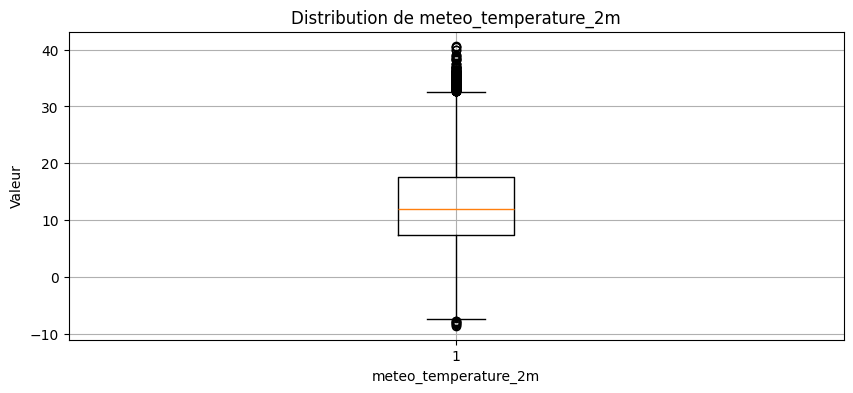

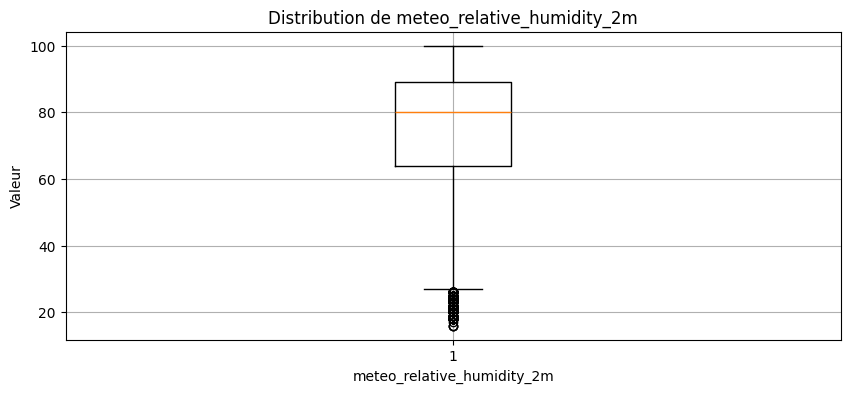

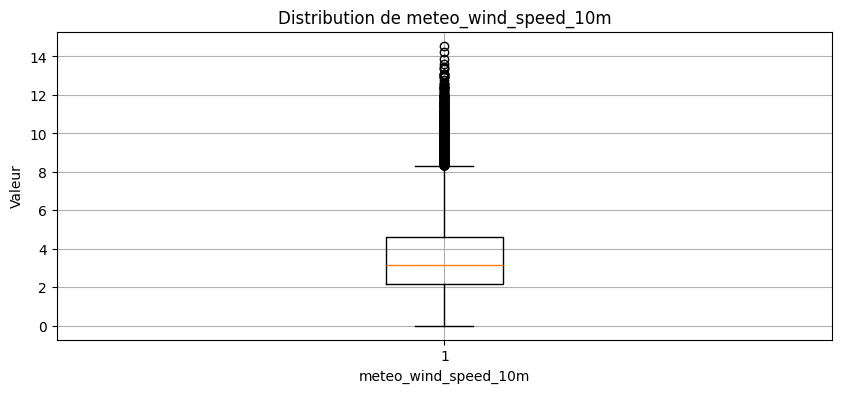

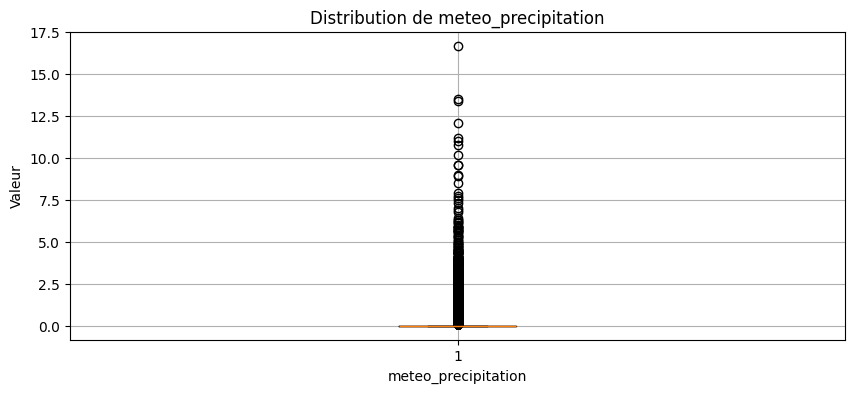

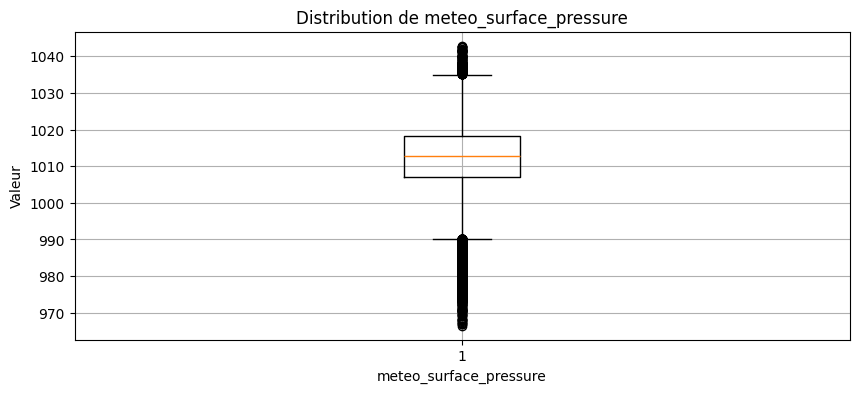

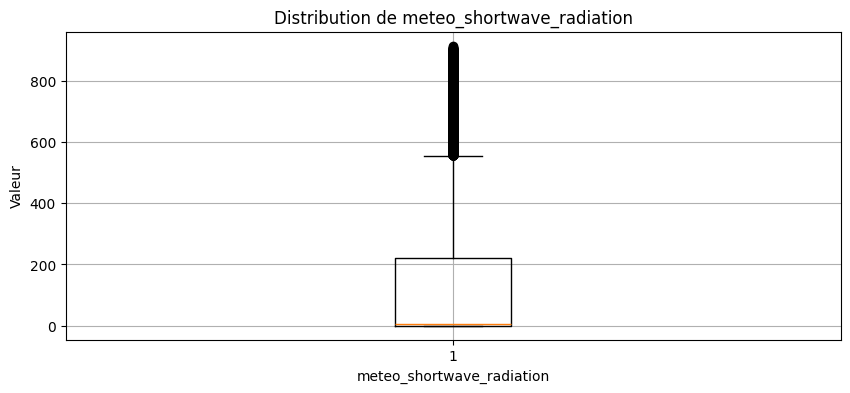

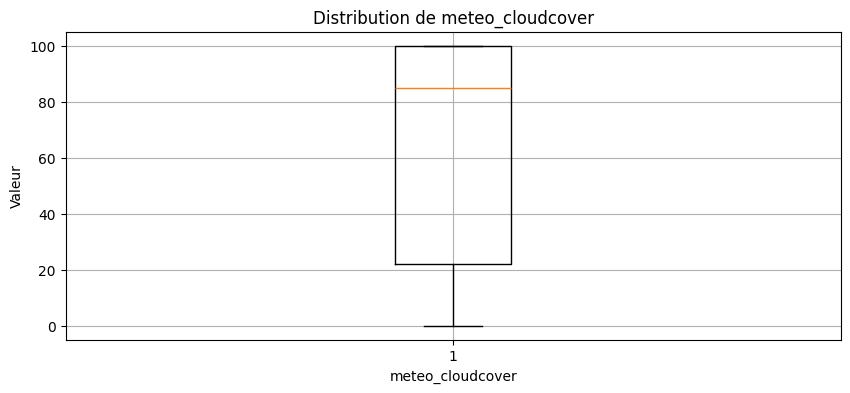

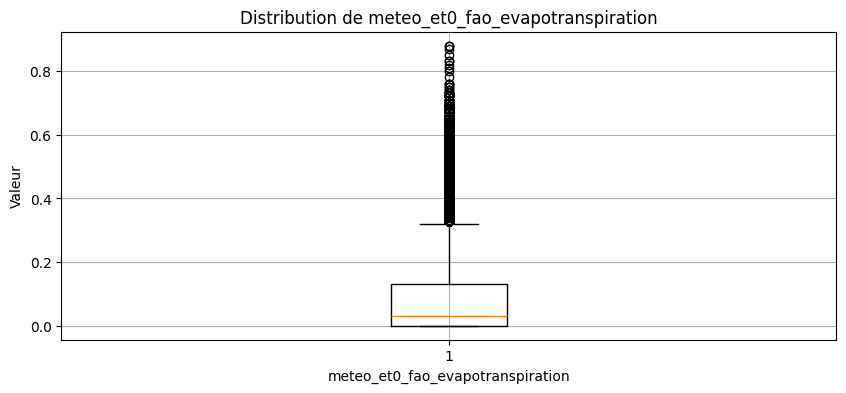

In [24]:
for col in df_raw.columns:
    if df_raw[col].dtype.kind in NUMERIC_KINDS:
        plt.figure(figsize=(10, 4))
        plt.boxplot(df_raw[col].dropna())
        plt.title(f"Distribution de {col}")
        plt.xlabel(col)
        plt.ylabel("Valeur")
        plt.grid(True)
        plt.show()

In [35]:
# on va donc enlever les outliers en se basant sur IQR
df = df_raw.copy()
meteo_cols = [c for c in df_raw.columns if c.startswith('meteo_')]
for col in meteo_cols:
    if df_raw[col].dtype.kind in NUMERIC_KINDS:
        series = df_raw[col].dropna()
        Q1, Q3 = series.quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        mask = (df_raw[col] < lower_bound) | (df_raw[col] > upper_bound)
        n_outlier = mask.sum()
        df.loc[mask, col] = np.nan
    print(f"Colonne {col} : {n_outlier} outliers détectés (seuil IQR)")

Colonne meteo_temperature_2m : 197 outliers détectés (seuil IQR)
Colonne meteo_relative_humidity_2m : 209 outliers détectés (seuil IQR)
Colonne meteo_wind_speed_10m : 1099 outliers détectés (seuil IQR)
Colonne meteo_precipitation : 10521 outliers détectés (seuil IQR)
Colonne meteo_surface_pressure : 1740 outliers détectés (seuil IQR)
Colonne meteo_shortwave_radiation : 4781 outliers détectés (seuil IQR)
Colonne meteo_cloudcover : 0 outliers détectés (seuil IQR)
Colonne meteo_et0_fao_evapotranspiration : 5766 outliers détectés (seuil IQR)


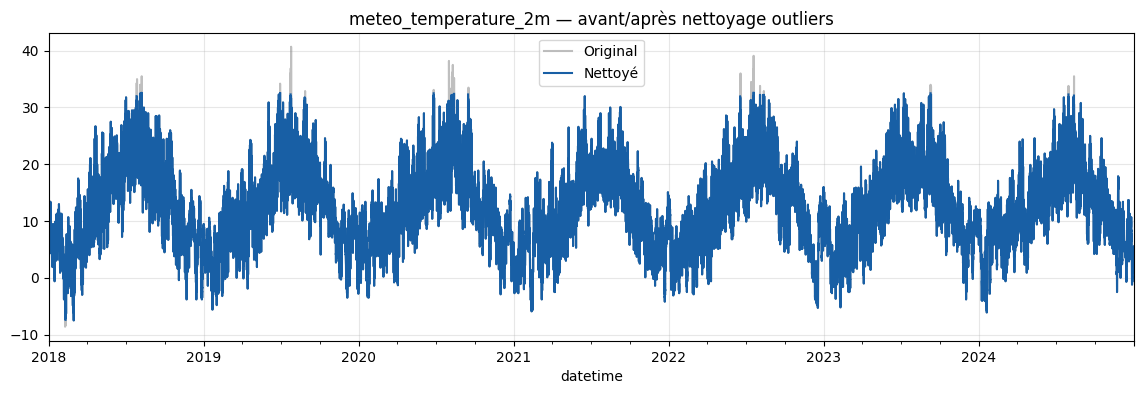

In [36]:
fig, ax = plt.subplots(figsize=(14, 4))
col = 'meteo_temperature_2m'
df_raw[col].plot(ax=ax, label='Original', alpha=0.5, color='gray')
df[col].plot(ax=ax, label='Nettoyé', color='#185FA5')
ax.set_title(f'{col} — avant/après nettoyage outliers')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [ ]:
# outlier avec z score
from scipy import stats

df = df_raw.copy()
for col in meteo_cols:
    if col not in df.columns:
        continue
    z = np.abs(stats.zscore(df[col].dropna()))
    # Retrouver les indices dans le df original
    non_null_idx = df[col].dropna().index
    extreme_idx  = non_null_idx[z > 5.0]
    if len(extreme_idx) > 0:
        df.loc[extreme_idx, col] = np.nan

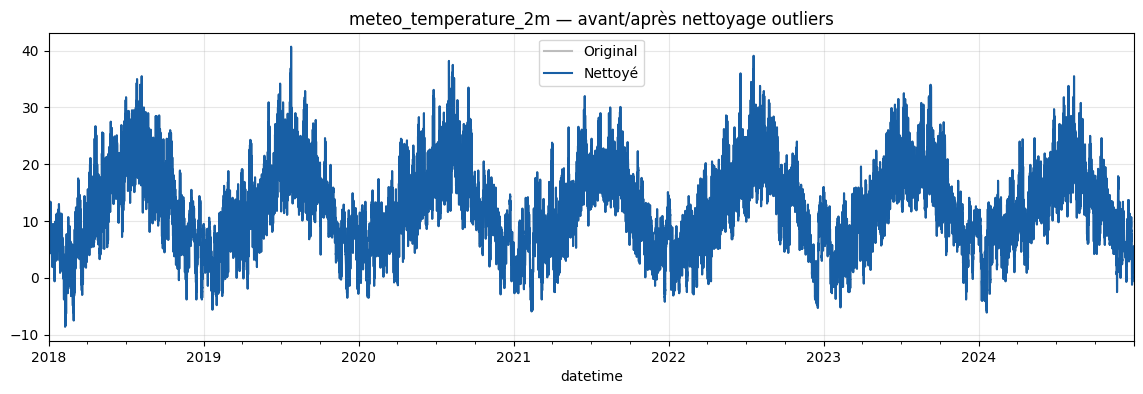

In [31]:
fig, ax = plt.subplots(figsize=(14, 4))
col = 'meteo_temperature_2m'
df_raw[col].plot(ax=ax, label='Original', alpha=0.5, color='gray')
df[col].plot(ax=ax, label='Nettoyé', color='#185FA5')
ax.set_title(f'{col} — avant/après nettoyage outliers')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

donc on voit bien que avce IQR les donnée sont plus propre par rapport à z-score.

In [34]:
# Time series imputation
df_clean = df.copy()
numeric_cols = df.select_dtypes(include=np.number).columns

df_clean[numeric_cols] = df_clean[numeric_cols].interpolate(method='time', limit=6, limit_direction='forward')  # interpolation linéaire temporelle, max 6h consécutives
df_clean[numeric_cols] = df_clean[numeric_cols].ffill(limit=24)  # fill forward up to 24h
df_clean[numeric_cols] = df_clean[numeric_cols].bfill(limit=24)  # fill backward up to 24h

total_nulls = df_clean[numeric_cols].isnull().sum().sum()
if total_nulls > 0:
    null_cols = df[numeric_cols].isnull().sum()
    null_cols = null_cols[null_cols > 0]
    print(f"{total_nulls} NaN restants après imputation :")
    for col, n in null_cols.items():
        print(f"{col} : {n}")
else:
    print('Aucun NaN restant après imputation')

143 NaN restants après imputation :
meteo_temperature_2m : 197
meteo_relative_humidity_2m : 209
meteo_wind_speed_10m : 1099
meteo_precipitation : 10521
meteo_surface_pressure : 1740
meteo_shortwave_radiation : 4781
meteo_et0_fao_evapotranspiration : 5766


In [37]:
print("null before imputation :", df[meteo_cols].isnull().sum())
print("null after imputation  :", df_clean[meteo_cols].isnull().sum())

null before imputation : meteo_temperature_2m                  197
meteo_relative_humidity_2m            209
meteo_wind_speed_10m                 1099
meteo_precipitation                 10521
meteo_surface_pressure               1740
meteo_shortwave_radiation            4781
meteo_cloudcover                        0
meteo_et0_fao_evapotranspiration     5766
dtype: int64
null after imputation  : meteo_temperature_2m                  0
meteo_relative_humidity_2m            0
meteo_wind_speed_10m                  0
meteo_precipitation                   0
meteo_surface_pressure              143
meteo_shortwave_radiation             0
meteo_cloudcover                      0
meteo_et0_fao_evapotranspiration      0
dtype: int64


In [38]:
df1 = df_clean.copy()
idx = df1.index

# Heure (cycle 24h)
df1["hour_sin"]   = np.sin(2 * np.pi * idx.hour / 24)
df1["hour_cos"]   = np.cos(2 * np.pi * idx.hour / 24)

# Jour de la semaine (cycle 7j)
df1["dow_sin"]    = np.sin(2 * np.pi * idx.dayofweek / 7)
df1["dow_cos"]    = np.cos(2 * np.pi * idx.dayofweek / 7)

# Mois (cycle 12m)
df1["month_sin"]  = np.sin(2 * np.pi * idx.month / 12)
df1["month_cos"]  = np.cos(2 * np.pi * idx.month / 12)

# Jour de l'année (cycle 365j) — saisonnalité annuelle fine
df1["doy_sin"]    = np.sin(2 * np.pi * idx.dayofyear / 365.25)
df1["doy_cos"]    = np.cos(2 * np.pi * idx.dayofyear / 365.25)

# Features calendaires binaires
df1["is_weekend"]  = (idx.dayofweek >= 5).astype(np.int8)
df1["is_daytime"]  = ((idx.hour >= 6) & (idx.hour < 20)).astype(np.int8)
df1["is_morning"]  = ((idx.hour >= 6) & (idx.hour < 12)).astype(np.int8)
df1["is_afternoon"]= ((idx.hour >= 12) & (idx.hour < 18)).astype(np.int8)

# Saison (hémisphère nord)
seasons = {12: 0, 1: 0, 2: 0,   # Hiver
            3: 1, 4: 1, 5: 1,    # Printemps
            6: 2, 7: 2, 8: 2,    # Été
            9: 3, 10: 3, 11: 3}  # Automne
df1["season"] = idx.month.map(seasons).astype(np.int8)

In [ ]:
# Lag features et rolling statistics pour la température à 2m
for lag in [1,6,24,168]:  # lags de 1h, 6h, 24h, 168h (1 semaine)
    df1[f"meteo_temperature_2m_lag_{lag}h"] = df1["meteo_temperature_2m"].shift(lag)

for w in [6, 24, 168]:  # fenêtres de 6h, 24h, 168h (1 semaine)
    label = f"{w}h" if w < 168 else "7d"
    series = df1["meteo_temperature_2m"]

    df1[f"meteo_temperature_2m_roll_mean_{label}"]  = series.rolling(w, min_periods=max(1, w // 4)).mean()
    df1[f"meteo_temperature_2m_roll_std_{label}"]   = series.rolling(w, min_periods=max(1, w // 4)).std()
    df1[f"meteo_temperature_2m_roll_min_{label}"]   = series.rolling(w, min_periods=max(1, w // 4)).min()
    df1[f"meteo_temperature_2m_roll_max_{label}"]   = series.rolling(w, min_periods=max(1, w // 4)).max()
    df1[f"meteo_temperature_2m_roll_range_{label}"] = (
        df1[f"meteo_temperature_2m_roll_max_{label}"] - df1[f"meteo_temperature_2m_roll_min_{label}"]
    )

    # Exponentially Weighted Mean (réactivité aux changements récents)
    df1[f"meteo_temperature_2m_ewm_{label}"] = series.ewm(span=w, min_periods=1).mean()

In [41]:
# Différences et taux de variation
for d in [1, 24, 168]:  # différences de 1h, 24h, 168h (1 semaine)
    label = f"{d}h" if d < 168 else "7d"
    df1[f"meteo_temperature_2m_diff_{label}"] = df1["meteo_temperature_2m"].diff(d)
    # Taux de variation en %
    df1[f"meteo_temperature_2m_pct_{label}"] = df1["meteo_temperature_2m"].pct_change(d).clip(-2, 2)

if "meteo_temperature_2m" in df1.columns and "meteo_relative_humidity_2m" in df1.columns:
    T  = df1["meteo_temperature_2m"]
    RH = df1["meteo_relative_humidity_2m"]
    W  = df1.get("meteo_wind_speed_10m", pd.Series(0, index=df1.index))

    # Pression de vapeur saturante (formule de Magnus)
    e  = 6.112 * np.exp(17.67 * T / (T + 243.5))
    es = RH / 100 * e

    # Humidex (Masterton & Richardson, 1979)
    df1["meteo_humidex"] = T + 0.5555 * (es - 10)

    # Windchill (formule de Siple & Passel simplifiée, valide si T < 10°C et W > 1.3 m/s)
    W_kmh = W * 3.6
    windchill = (
        13.12 + 0.6215 * T
        - 11.37 * (W_kmh ** 0.16)
        + 0.3965 * T * (W_kmh ** 0.16)
    )
    # Appliquer seulement si conditions valides
    valid_wc = (T < 10) & (W > 1.3)
    df1["meteo_windchill"] = np.where(valid_wc, windchill, T)

    # Température ressentie globale
    df1["meteo_apparent_temp"] = np.where(
        T > 27, df1["meteo_humidex"],
        np.where(T < 10, df1["meteo_windchill"], T)
    )

# Radiation solaire normalisée (0-1)
if "meteo_shortwave_radiation" in df1.columns:
    max_radiation = df1["meteo_shortwave_radiation"].quantile(0.999)
    df1["meteo_radiation_norm"] = (
        df1["meteo_shortwave_radiation"] / (max_radiation + 1e-8)
    ).clip(0, 1)

In [43]:
print(f'Features générées : {df1.shape[1]} colonnes')
print('\nNouveaux features :', [c for c in df1.columns if c not in df_clean.columns][:10])

Features générées : 53 colonnes

Nouveaux features : ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'is_weekend', 'is_daytime']


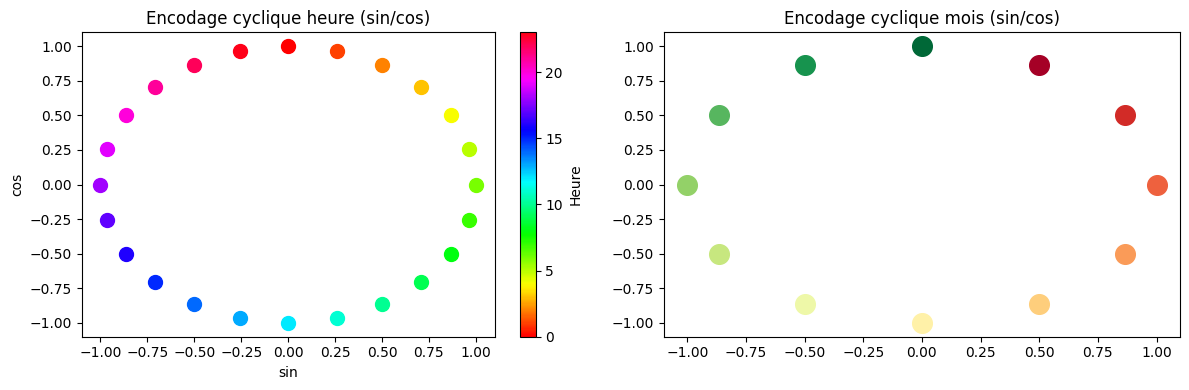

In [45]:
# Encodage cyclique : vérification
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for h in range(24):
    subset = df1[df1.index.hour == h][['hour_sin', 'hour_cos']].mean()
    axes[0].scatter(subset['hour_sin'], subset['hour_cos'], c=[h], cmap='hsv', vmin=0, vmax=23, s=100)
axes[0].set_title('Encodage cyclique heure (sin/cos)')
axes[0].set_xlabel('sin')
axes[0].set_ylabel('cos')
plt.colorbar(axes[0].collections[0], ax=axes[0], label='Heure')
for m in range(1, 13):
    subset = df1[df1.index.month == m][['month_sin', 'month_cos']].mean()
    axes[1].scatter(subset['month_sin'], subset['month_cos'], c=[m], cmap='RdYlGn', vmin=1, vmax=12, s=200)
axes[1].set_title('Encodage cyclique mois (sin/cos)')
plt.tight_layout()
plt.savefig('../reports/figures/cyclical_encoding.png', dpi=150)
plt.show()

# yfinance

un peu similaire pour correpond aux index de meteo